# 🌱 Relatório Estatístico — Registro Nacional de Cultivares (RNC)

> **Fonte de dados:** `relatorio_cultivares.csv`  
> **Filtro Aplicado:** Excluindo registros de 2026

---

## Seções
1. [Carregamento e Pré-processamento](#1-carregamento)
2. [Cultivares Mais Comuns](#2-cultivares)
3. [Visão Geral das Colunas](#3-visao-geral)
4. [Crescimento Anual de Registros](#4-crescimento-anual)
5. [Classificação de Mantenedores por Setor](#5-setores)
6. [Setor Público — Detalhamento](#6-publico)
7. [Setor Misto — Detalhamento](#7-misto)
8. [Valores Nulos — Mantenedor](#8-nulos)
9. [Líderes: Soja e Milho](#9-soja-milho)
10. [Líderes por Cultivares Comuns](#10-lideres)

---
## 1. Carregamento e Pré-processamento <a id='1-carregamento'></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

COL_DATA       = 'DATA DO REGISTRO'
COL_MANTENEDOR = 'MANTENEDOR (REQUERENTE) (NOME)'
COL_NOME_COM   = 'NOME COMUM'

df = pd.read_csv('relatorio_cultivares.csv')
df[COL_DATA] = pd.to_datetime(df[COL_DATA], dayfirst=True, errors='coerce')
df['ANO'] = df[COL_DATA].dt.year
df = df[df['ANO'] != 2026]

PUB_KW = ['universidade', 'empresa brasileira', 'instituto', 'empresa de pesquisa agropecuária', 'departamento de sementes', 'secretaria da agricultura', 'agência goiana']
MISTO_KW = ['fundação', 'cooperativa']

def classify_setor(nome):
    if pd.isna(nome): return 'Nulo'
    n = nome.lower()
    for kw in PUB_KW: 
        if kw in n: return 'Público'
    for kw in MISTO_KW: 
        if kw in n: return 'Misto'
    return 'Privado'

df['SETOR'] = df[COL_MANTENEDOR].apply(classify_setor)

---
## 2. Cultivares Mais Comuns <a id='2-cultivares'></a>

In [2]:
top_cultivares = df.groupby(COL_NOME_COM).agg(Registros=(COL_NOME_COM, 'count')).reset_index().sort_values('Registros', ascending=False).head(30)
top_cultivares.index = range(1, 31)
display(top_cultivares.style.background_gradient(subset=['Registros'], cmap='YlGn'))

,NOME COMUM,Registros
1,Milho,6179
2,Soja,2728
3,Orquídea,1613
4,Tomate/Tomate-rasteiro,1396
5,Sorgo,1228
6,Crisântemo/Crisântemo-da-China,869
7,Alface,673
8,"Pimentão, Pimenta",654
9,Eucalipto,613
10,Fumo/Tabaco,524


---
## 3. Visão Geral das Colunas <a id='3-visao-geral'></a>

In [3]:
res_col = pd.DataFrame({'Tipo': df.drop(columns='SETOR').dtypes.astype(str), 'Nulos': df.drop(columns='SETOR').isnull().sum(), '% Nulos': (df.drop(columns='SETOR').isnull().sum()/len(df)*100).round(2)})
res_col.style.background_gradient(subset=['% Nulos'], cmap='Reds')

,Tipo,Nulos,% Nulos
CULTIVAR,str,3570,9.620000
NOME COMUM,str,0,0.000000
NOME CIENTÍFICO,str,0,0.000000
GRUPO DA ESPÉCIE,str,0,0.000000
SITUAÇÃO,str,0,0.000000
Nº FORMULÁRIO,float64,23639,63.720000
Nº REGISTRO,int64,0,0.000000
DATA DO REGISTRO,datetime64[us],0,0.000000
DATA DE VALIDADE DO REGISTRO,str,0,0.000000
MANTENEDOR (REQUERENTE) (NOME),str,3669,9.890000


---
## 4. Crescimento Anual de Registros <a id='4-crescimento-anual'></a>

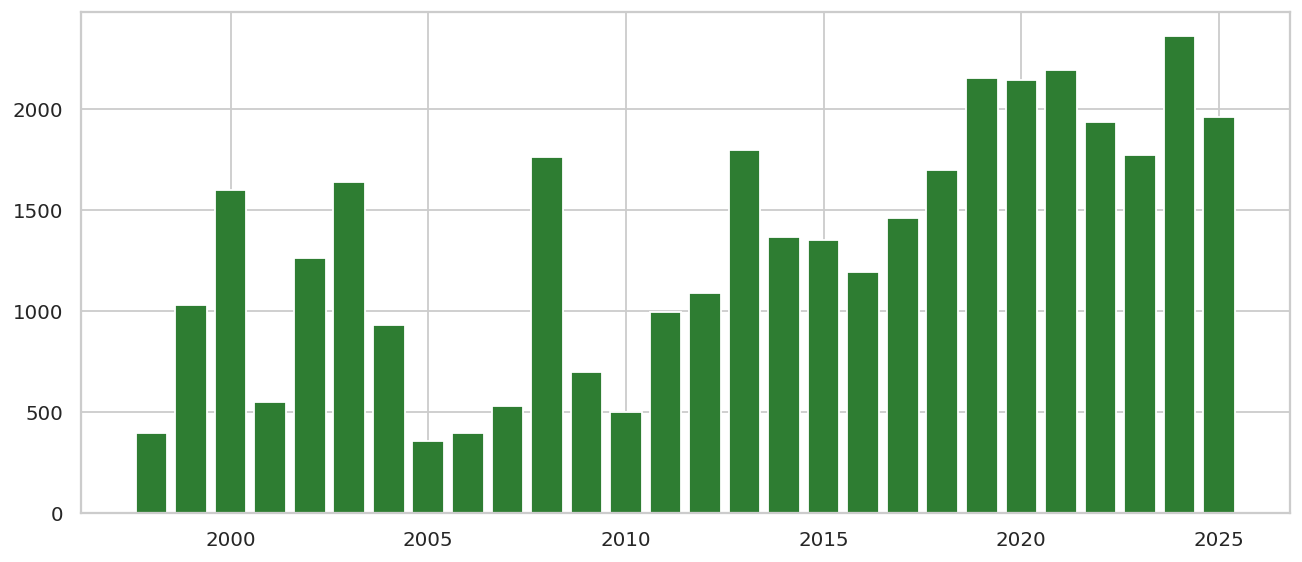

In [4]:
reg_ano = df.groupby('ANO').size().reset_index(name='Registros').set_index('ANO')
fig, ax = plt.subplots(); ax.bar(reg_ano.index.astype(int), reg_ano['Registros'], color='#2E7D32'); plt.show()

---
## 5. Classificação de Mantenedores por Setor <a id='5-setores'></a>

In [5]:
dist = df['SETOR'].value_counts().to_frame(); display(dist.style.background_gradient(cmap='Blues'))

,count
SETOR,
Privado,29639
Nulo,3669
Público,3648
Misto,145


---
## 6. Setor Público — Detalhamento <a id='6-publico'></a>

In [6]:
df_pub = df[df['SETOR'] == 'Público'].copy()
top_pub = df_pub[COL_MANTENEDOR].value_counts().head(20).reset_index()
top_pub.index = range(1, 21)
display(top_pub.style.background_gradient(cmap='Blues'))

,MANTENEDOR (REQUERENTE) (NOME),count
1,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,1851
2,INSTITUTO AGRONÔMICO - IAC,695
3,INSTITUTO DE DESENVOLVIMENTO RURAL DO PARANÁ - IAPAR-EMATER,202
4,EMPRESA DE PESQUISA AGROPECUÁRIA E EXTENSÃO RURAL DE SANTA CATARINA - EPAGRI,183
5,EMPRESA DE PESQUISA AGROPECUÁRIA DE MINAS GERAIS - EPAMIG,122
6,UNIVERSIDADE ESTADUAL DO NORTE FLUMINENSE DARCY RIBEIRO - UENF,55
7,UNIVERSIDADE FEDERAL DE VIÇOSA-UFV,53
8,INSTITUTO MATO-GROSSENSE DO ALGODÃO - IMAMT,50
9,UNIVERSIDADE FEDERAL DE UBERLÂNDIA-UFU,35
10,Universidade do Estado do Mato Grosso - UNEMAT,31


---
## 7. Setor Misto — Detalhamento <a id='7-misto'></a>

In [7]:
display(df[df['SETOR'] == 'Misto'][COL_MANTENEDOR].value_counts().head(20).reset_index().style.background_gradient(cmap='YlOrBr'))

,MANTENEDOR (REQUERENTE) (NOME),count
0,FUNDAÇÃO DE APOIO À TECNOLOGIA CAFEEIRA- FUNDAÇÃO PROCAFÉ,47
1,COOPERATIVA VINICOLA GARIBALDI LTDA,24
2,FUNDAÇÃO DE APOIO À PESQUISA AGROPECUÁRIA DE MATO GROSSO - FUNDAÇÃO MT,23
3,FUNDAÇÃO PRÓ-SEMENTES DE APOIO À PESQUISA,12
4,FUNDAÇÃO AGRÁRIA DE PESQUISA AGROPECUÁRIA - FAPA,8
5,COOPERATIVA VEILING HOLAMBRA,8
6,COOPERATIVA AGROECOLÓGICA NACIONAL TERRA E VIDA LTDA - COONATERRA,6
7,FUNDAÇÃO MS PARA PESQUISA E DIFUSÃO DE TECNOLOGIAS,4
8,COOPERATIVA AGRÁRIA AGROINDUSTRIAL,4
9,"Fundação de Integração, Desenvolvimento e Educação do Noroeste do Estado do Rio Grande do Sul",3


---
## 8. Valores Nulos — Mantenedor <a id='8-nulos'></a>

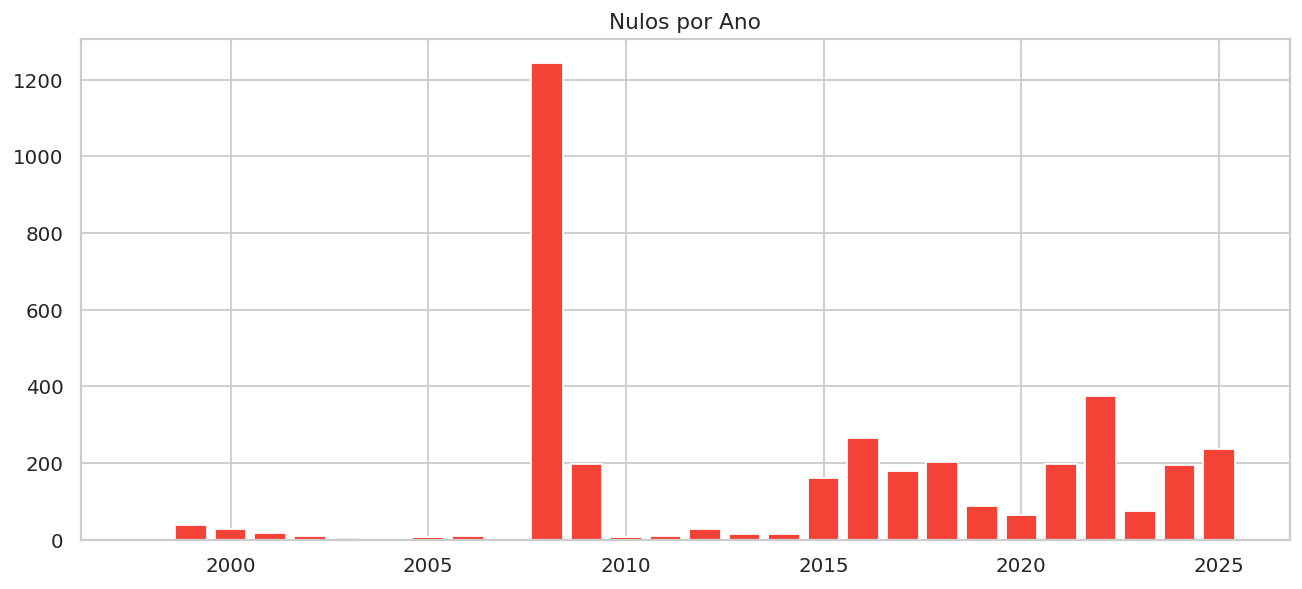

In [8]:
nl = df[df[COL_MANTENEDOR].isnull()].groupby('ANO').size()
plt.bar(nl.index.astype(int), nl.values, color='#F44336'); plt.title('Nulos por Ano'); plt.show()

---
## 9. Líderes: Soja e Milho <a id='9-soja-milho'></a>

In [9]:
top5_soja = df[df[COL_NOME_COM].str.upper().str.contains('SOJA', na=False)][COL_MANTENEDOR].value_counts().head(5).reset_index()
top5_soja.columns = ['Mantenedor Soja', 'Registros']
top5_soja.index = range(1, 6)

top5_milho = df[df[COL_NOME_COM].str.upper().str.contains('MILHO', na=False)][COL_MANTENEDOR].value_counts().head(5).reset_index()
top5_milho.columns = ['Mantenedor Milho', 'Registros']
top5_milho.index = range(1, 6)

print("🟢 TOP 5 MANTENEDORES DE SOJA")
display(top5_soja.style.background_gradient(cmap='Greens'))
print("\n🟡 TOP 5 MANTENEDORES DE MILHO")
display(top5_milho.style.background_gradient(cmap='Oranges'))

🟢 TOP 5 MANTENEDORES DE SOJA


,Mantenedor Soja,Registros
1,GDM GENÉTICA DO BRASIL S.A.,702
2,SYNGENTA SEEDS LTDA.,576
3,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,331
4,TMG TROPICAL MELHORAMENTO E GENETICA S.A.,174
5,D&PL BRASIL LTDA.,131



🟡 TOP 5 MANTENEDORES DE MILHO


,Mantenedor Milho,Registros
1,CORTEVA AGRISCIENCE DO BRASIL LTDA.,1717
2,MONSANTO DO BRASIL LTDA.,1360
3,SYNGENTA SEEDS LTDA.,748
4,LONGPING HIGH-TECH BIOTECNOLOGIA LTDA.,403
5,GDM GENÉTICA DO BRASIL S.A.,164


---
## 10. Mantenedores nas Cultivares Mais Comuns <a id='10-lideres'></a>

In [10]:
pop_30 = df[COL_NOME_COM].value_counts().head(30).index
t_mant = df[df[COL_NOME_COM].isin(pop_30)][COL_MANTENEDOR].value_counts().head(20).reset_index()
t_mant.index = range(1, 21)
display(t_mant.style.background_gradient(cmap='Purples'))

,MANTENEDOR (REQUERENTE) (NOME),count
1,CORTEVA AGRISCIENCE DO BRASIL LTDA.,1917
2,SYNGENTA SEEDS LTDA.,1483
3,MONSANTO DO BRASIL LTDA.,1386
4,SAKATA SEED SUDAMERICA LTDA,1168
5,EMPRESA BRASILEIRA DE PESQUISA AGROPECUÁRIA - EMBRAPA,1063
6,GDM GENÉTICA DO BRASIL S.A.,1008
7,KARÍS COMÉRCIO DE INSUMOS AGRÍCOLAS LTDA,1004
8,Nicolaas Josef Schoenmaker e Outros,917
9,AGRISTAR DO BRASIL LTDA,642
10,ALVIM SEIDEL ORQUIDáRIO CATARINENSE LTDA.,626
